# Chapter 14: Classifying Images with Deep Convolutional Neural Networks (Part 2/2)

In [1]:
import torch
import torch.nn as nn
import numpy as np

from IPython.display import Image

import matplotlib.pyplot as plt
%matplotlib inline

## 14.4. Классификация улыбающихся лиц с помощью CNN 

В этом разделе мы построим CNN для классификации улыбающихся лиц с использованием набора данных CelebA. Как было сказано в главе 12, набор данных CelebA содержит 202 599 изображений лиц знаменитостей. Кроме того, для каждого изображения доступно 40 бинарных атрибутов лица, отражающих в том числе, улыбается знаменитость или нет, и ее возраст (молодая или пожилая). Цель этого раздела - основываясь на полученных вами знаниях, построить и обучить модель CNN для прогнозирования наличия улыбки на изображениях лиц. Здесь для простоты - чтобы ускорить процесс обучения - мы задействуем только небольшую часть обучающих данных (16 тыс. обучающих примеров). Однако для улучшения качества обобщения и уменьшения времени переобучения на таком небольшом наборе данных мы применим метод, называемый дополнением данных (data augmentation). 

### 14.4.1. Загрузка набора данных Сеlеba

Начнем мы с загрузки данных - аналогично тому, как мы это делали в предыдущем разделе для набора данных МNIST. Данные CelebA поставляются с разбивкой на три набора: для обучения, для валидации и для тестирования. С помощью следующего кода мы подсчитаем количество примеров в каждом разделе: 

In [2]:
import torchvision 
image_path = './'
celeba_train_dataset = torchvision.datasets.CelebA(image_path, split='train', target_type='attr', download=False)
celeba_valid_dataset = torchvision.datasets.CelebA(image_path, split='valid', target_type='attr', download=False)
celeba_test_dataset = torchvision.datasets.CelebA(image_path, split='test', target_type='attr', download=False)

print('Train set:', len(celeba_train_dataset))
print('Validation set:', len(celeba_valid_dataset))
print('Test set:', len(celeba_test_dataset))

Train set: 162770
Validation set: 19867
Test set: 19962


Тип изображения: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Размер: (178, 218)
Атрибуты: tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1])


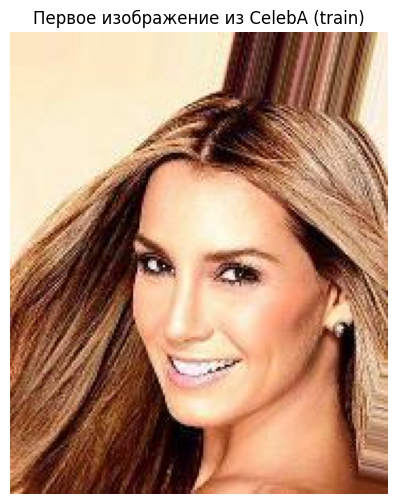

In [3]:
# Берём первое изображение
img, attrs = celeba_train_dataset[0]
# Проверяем формат: обычно это PIL Image
print(f"Тип изображения: {type(img)}")
print(f"Размер: {img.size}") # (ширина, высота)
print(f"Атрибуты: {attrs}") # (ширина, высота)
# Отображаем
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Первое изображение из CelebA (train)")
plt.axis('off')      # убираем оси
plt.show()

### 14.4.2. Преобразование изображений и дополнение данных 

Дополнение данных охватывает широкий набор методов для работы со случаями, когда данные для обучения ограниченны. Например, некоторые методы дополнения данных позволяют нам изменять или даже искусственно синтезировать дополнительные данные и тем самым увеличивать производительность модели глубокого обучения за счет снижения переобучения. Хотя дополнение данных применяют не только к изображениям, существует набор преобразований, предназначенных специально для изображений, - таких как обрезка частей изображения, зеркальное отражение и изменение контраста, яркости и насыщенности. Давайте рассмотрим некоторые из этих преобразований, доступных через модуль torchvision.transforms. В следующем блоке кода мы
извлечем пять примеров из набора данных celeba_train_dataset и применим пять различных типов преобразования:
1) обрезка изображения до ограничительной рамки;
2) отражение изображения по горизонтали; 
3) изменение контрастности; 
4) изменение яркости; 
5) обрезка изображения по центру и изменение размера полученного изображения до исходного размера (218, 178). 

В приведенном далее коде мы визуализируем результаты этих преобразований, показывая каждое в отдельном столбце для сравнения: 

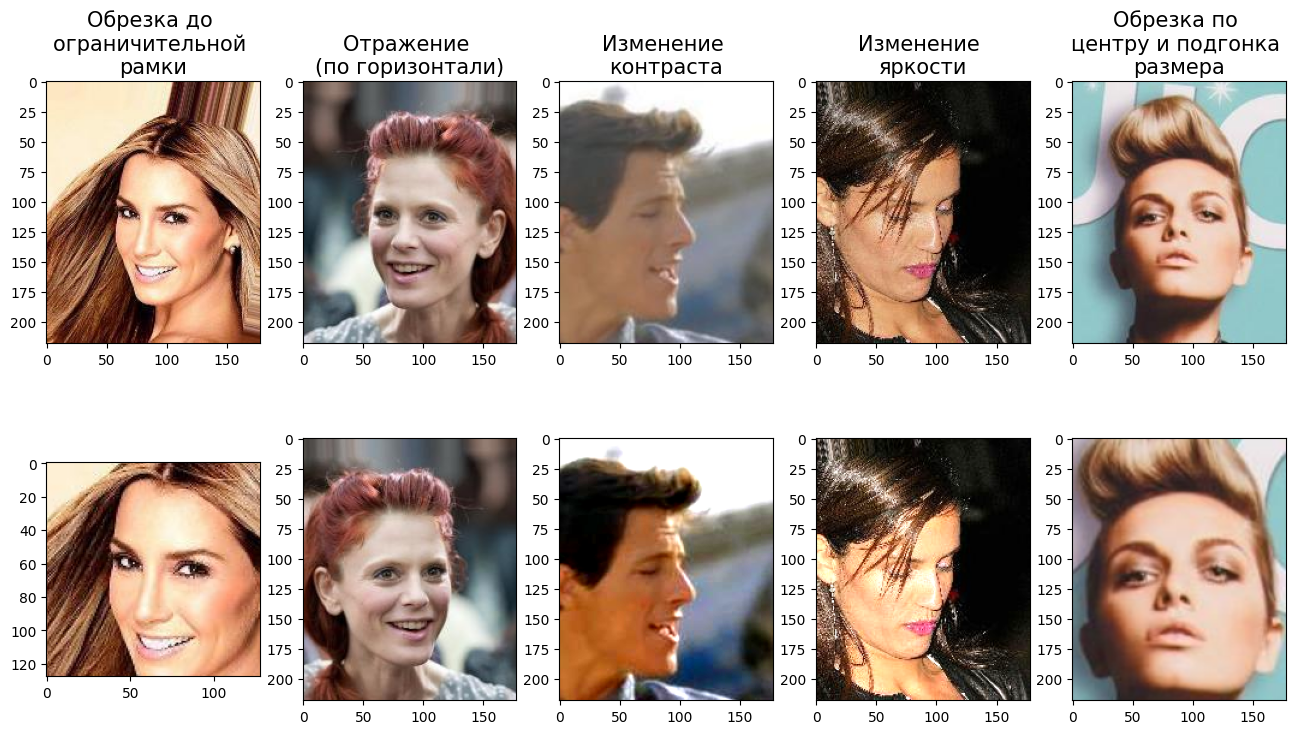

In [4]:
from torchvision import transforms 

## take 5 examples

fig = plt.figure(figsize=(16, 8.5))

## Столбец 1: обрезка до ограничительной рамки 
ax = fig.add_subplot(2, 5, 1)
img, attr = celeba_train_dataset[0]
ax.set_title('Oбpeзкa до \nограничительной \nрамки', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 6)
# crop() — вырезает прямоугольник из исходного изображения.
# Параметры: (изображение, top, left, height, width).
# top=50 — отступ сверху.
# left=20 — отступ слева.
# height=128 — высота вырезаемой области.
# width=128 — ширина вырезаемой области.
# Результат: обрезанное изображение размером 128×128 пикселей.
img_cropped = transforms.functional.crop(img, 50, 20, 128, 128)
ax.imshow(img_cropped)

## толбец 2: отражение (по горизонтали) 
ax = fig.add_subplot(2, 5, 2)
img, attr = celeba_train_dataset[1]
ax.set_title('Oтpaжeниe \n(по горизонтали)', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 7)
img_flipped = transforms.functional.hflip(img)
ax.imshow(img_flipped)

## Cтолбец 3: изменение контраста
ax = fig.add_subplot(2, 5, 3)
img, attr = celeba_train_dataset[2]
ax.set_title('Изменение \nконтраста', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 8)
# увеличивает контрастность в 2 раза. Разница между яркими и тёмными участками усиливается. 
# При contrast_factor=1 ничего не меняется, при >1 контраст растёт, при <1 — падает.
img_adj_contrast = transforms.functional.adjust_contrast(img, contrast_factor=2)
ax.imshow(img_adj_contrast)

## толбец 4: изменение яркости 
ax = fig.add_subplot(2, 5, 4)
img, attr = celeba_train_dataset[3]
ax.set_title('Изменение \nяркости', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 9)
# увеличивает яркость в 1.3 раза.
# Это симулирует изменение освещения: более яркое или тёмное изображение.
img_adj_brightness = transforms.functional.adjust_brightness(img, brightness_factor=1.3)
ax.imshow(img_adj_brightness)

## Cтолбец 5: обрезка относительно центра 
ax = fig.add_subplot(2, 5, 5)
img, attr = celeba_train_dataset[4]
ax.set_title('Oбpeзкa по \nцентру и подгонка \nразмера', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 10)
# center_crop(img, [0.7*218, 0.7*178]) — вырезает из центра изображения прямоугольник.
# 218 и 178 — это исходные размеры изображения (обычно для CelebA это 218×178 пикселей).
# 0.7*218 ≈ 153, 0.7*178 ≈ 125 → вырезается прямоугольник 153×125 из центра.
# Важно: center_crop ожидает либо одно число (квадрат), либо кортеж (height, width). Здесь он получает список, но это тоже работает.
img_center_crop = transforms.functional.center_crop(img, [0.7*218, 0.7*178])
# resize(img_center_crop, size=(218, 178)) — растягивает обрезанный прямоугольник обратно до исходного размера 218×178.
# Итог: вы как бы «приблизили» центр изображения, удалив края и увеличив масштаб центральной части.
img_resized = transforms.functional.resize(img_center_crop, size=(218, 178))
ax.imshow(img_resized)

plt.show()

На рис. 14.15 показаны результаты произведенных преобразований. Здесь исходные изображения приведены в первой строке, а их преобразованные версии - во второй. Обратите внимание, что для первого преобразования (крайний левый столбец) ограничивающая рамка определяется четырьмя числами: координатой верхнего левого угла ограничивающей рамки (здесь х = 20, у= 50), а также шириной и высотой рамки (ширина= 128, высота= 128). Точкой начала координат (0, 0) для изображений, загружаемых PyTorch (а также другими пакетами, такими как imageio), является верхний левый угол изображения.
Преобразования в приведенном блоке кода являются детерминированными. Однако все подобные преобразования также можно рандомизировать, что рекомендуется делать при дополнении обучающих данных. Например, можно выполнить обрезку по случайной ограничивающей рамке (когда координаты верхнего левого угла рамки генерируются случайным образом), изображение может быть случайным образом перевернуто либо по горизонтальной, либо по вертикальной оси с вероятностью 0.5, или коэффициент изменения контрастности можно выбирать из заданного диапазона случайным образом, но с равномерным распределением . Кроме того, можно создать последовательность преобразований. 

Например, мы можем сначала произвольно обрезать изображение, затем случайным образом отразить его и, наконец, изменить его размер до нужных значений. Поскольку у нас используются случайные элементы, мы задаем случайное начальное число для воспроизводимости результатов работы кода: 

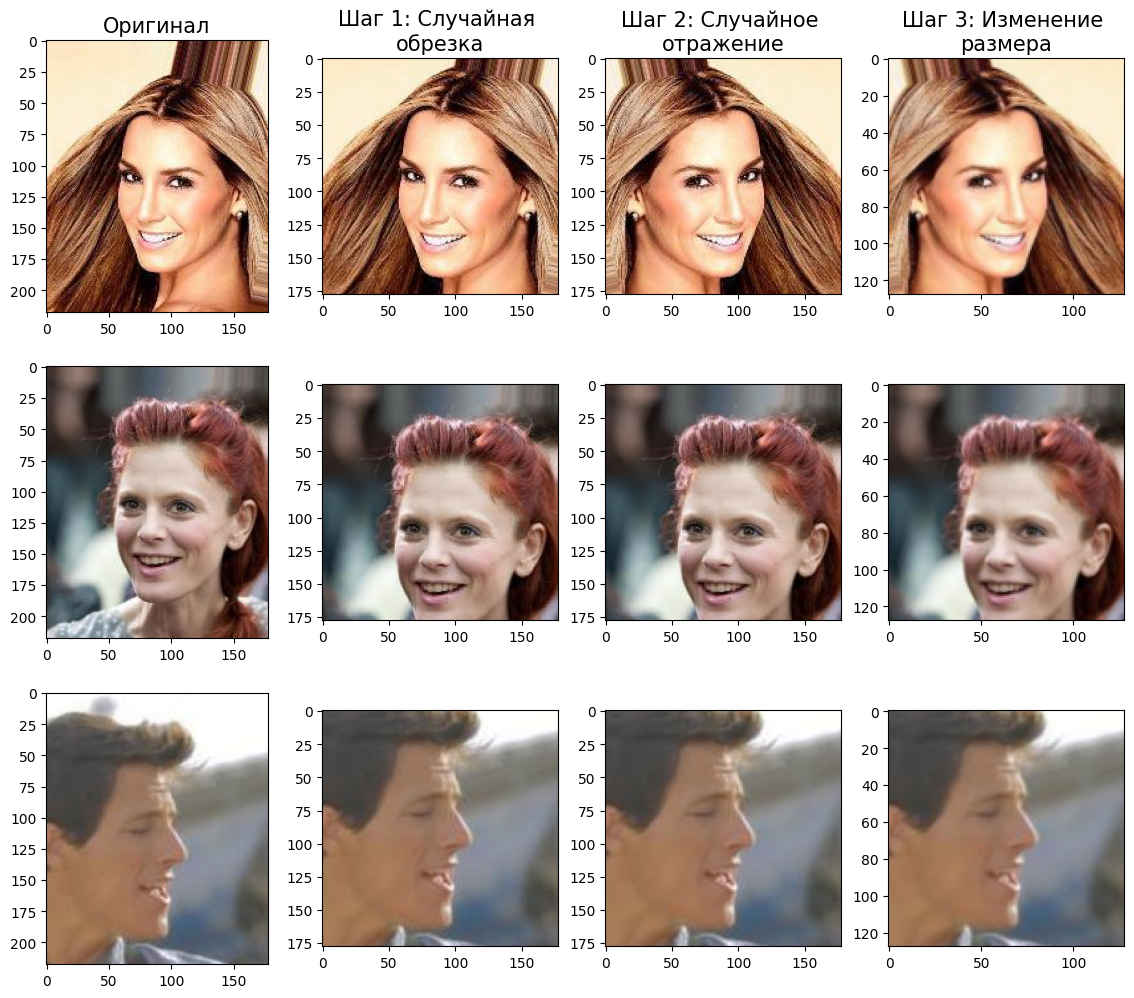

In [5]:
torch.manual_seed(1)

fig = plt.figure(figsize=(14, 12))

for i, (img, attr) in enumerate(celeba_train_dataset):
    ax = fig.add_subplot(3, 4, i*4+1)
    ax.imshow(img)
    if i == 0:
        ax.set_title('Opигинaл', size=15)
        
    ax = fig.add_subplot(3, 4, i*4+2)
# оздаёт объект-композицию с одной трансформацией: RandomCrop([178, 178]).
# Эта трансформация вырезает из изображения случайный прямоугольник размером 178×178 пикселей.
    img_transform = transforms.Compose([transforms.RandomCrop([178, 178])])
    img_cropped = img_transform(img)
    ax.imshow(img_cropped)
    if i == 0:
        ax.set_title('Шaг 1: Случайная \nобрезка', size=15)

    ax = fig.add_subplot(3, 4, i*4+3)
# Создаёт композицию с трансформацией RandomHorizontalFlip().
# Она с вероятностью 50% отражает изображение по горизонтали.
    img_transform = transforms.Compose([transforms.RandomHorizontalFlip()])
    img_flip = img_transform(img_cropped)
    ax.imshow(img_flip)
    if i == 0:
        ax.set_title('Шaг 2: Случайное \nотражение', size=15)

    ax = fig.add_subplot(3, 4, i*4+4)
# Берёт изображение после отражения (img_flip) и изменяет его размер до 128×128 пикселей.
# Используется функция resize из модуля transforms.functional (не Compose).
    img_resized = transforms.functional.resize(img_flip, size=(128, 128))
    ax.imshow(img_resized)
    if i == 0:
        ax.set_title('Шaг 3: Изменение \nразмера', size=15)
    
    if i == 2:
        break

plt.show()

На рис. 14.16 показаны случайные преобразования трех примеров изображений. При каждой новой обработке этих трех примеров, мы будем получать немного разные изображения из-за случайного компонента преобразований. Для удобства мы можем определить функции преобразования, чтобы использовать этот
конвейер для дополнения данных во время загрузки набора. В следующем коде мы определим функцию get_smile, которая будет извлекать метку улыбки из списка 'attributes': 

In [6]:
get_smile = lambda attr: attr[31]

Мы также определим функцию transform_train, которая создаст преобразованное изображение (где мы сначала произвольно обрежем изображение, затем случайным образом отразим его и, наконец, изменим его размер до желаемого размера 64хб4): 

In [7]:
transform_train = transforms.Compose([
    transforms.RandomCrop([178, 178]),
    transforms.RandomHorizontalFlip(),
    transforms.Resize([64, 64]),
    transforms.ToTensor(),
])

Однако мы будем применять дополнение данных только к обучающим примерам, а не к проверочным или тестовым изображениям. Код для обработки валидационного или тестового набора выглядит следующим образом (здесь мы сначала просто обрежем изображение, а затем изменим его до нужного размера 64хб4): 

In [8]:
transform = transforms.Compose([
    transforms.CenterCrop([178, 178]),
    transforms.Resize([64, 64]),
    transforms.ToTensor(),
])

Теперь, чтобы увидеть дополнение данных в действии, применим функцию transform_train к нашему набору обучающих данных и пройдем по набору данных пять раз:

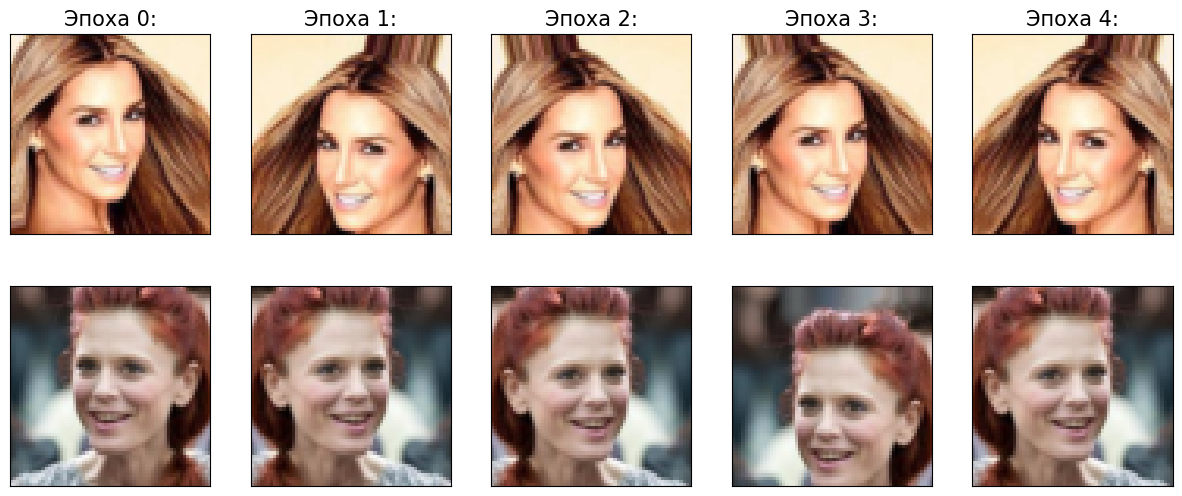

In [9]:
from torch.utils.data import DataLoader

celeba_train_dataset = torchvision.datasets.CelebA(image_path, 
                                                   split='train', 
                                                   target_type='attr', 
                                                   download=False, 
                                                   transform=transform_train,
                                                   target_transform=get_smile)

torch.manual_seed(1)
data_loader = DataLoader(celeba_train_dataset, batch_size=2)

fig = plt.figure(figsize=(15, 6))

num_epochs = 5
for j in range(num_epochs):
# iter(data_loader) — создаёт итератор по DataLoader.
# next() — запрашивает следующий батч.
# На каждой итерации загружается новый батч из 2 изображений и соответствующих им меток.
# При этом каждый раз создаётся новый итератор с помощью iter(), поэтому фактически вы каждый раз берёте первый батч из датасета, 
# а не разные батчи на разных эпохах (потому что data_loader не сбрасывается, и каждый раз создаётся новый итератор с начала).
    img_batch, label_batch = next(iter(data_loader))
    img = img_batch[0]
    ax = fig.add_subplot(2, 5, j + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Эпоха {j}:', size=15)
# Отображает изображение.
# img — тензор формата [C, H, W] (каналы, высота, ширина).
# .permute(1, 2, 0) меняет порядок на [H, W, C] — так ожидает matplotlib.imshow().
    ax.imshow(img.permute(1, 2, 0))

    img = img_batch[1]
    ax = fig.add_subplot(2, 5, j + 6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(img.permute(1, 2, 0))
      
plt.show()



Далее мы применим функцию transform к нашим наборам данных для валидации и тестирования: 

In [10]:
celeba_valid_dataset = torchvision.datasets.CelebA(image_path, 
                                                   split='valid', 
                                                   target_type='attr', 
                                                   download=False, 
                                                   transform=transform,
                                                   target_transform=get_smile)

celeba_test_dataset = torchvision.datasets.CelebA(image_path, 
                                                   split='test', 
                                                   target_type='attr', 
                                                   download=False, 
                                                   transform=transform,
                                                   target_transform=get_smile)

Вместо того чтобы использовать все доступные данные для обучения и валидации, мы возьмем подмножество из 16 тыс. обучающих примеров и 1000 примеров для валидации, поскольку наша цель здесь - намеренно обучить нашу модель с небольшим набором данных: 

In [11]:
from torch.utils.data import Subset
celeba_train_dataset = Subset(celeba_train_dataset, torch.arange(16000)) 
celeba_valid_dataset = Subset(celeba_valid_dataset, torch.arange(1000)) 
 
print('Haбop для обучения:', len(celeba_train_dataset))
print('Набор для валидации:', len(celeba_valid_dataset))

Haбop для обучения: 16000
Набор для валидации: 1000


Теперь мы можем создать загрузчики данных для трех наборов данных: 

In [12]:
batch_size = 32

torch.manual_seed(1)
train_dl = DataLoader(celeba_train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(celeba_valid_dataset, batch_size, shuffle=False)
test_dl = DataLoader(celeba_test_dataset, batch_size, shuffle=False)

Итак, загрузчики данных готовы, и в следующем разделе мы разработаем модель CNN,
а также обучим ее и оценим точность классификации. 

### 14.4.З. Обучение классификатора улыбки на основе CNN 

К настоящему времени создание модели с помощью модуля torch.nn и ее обучение не должно вызывать у вас затруднений.
Наша CNN устроена так: модель получает на вход изображения размером Зх64х64 (три цветовых канала). Входные данные проходят через четыре сверточных слоя для создания 32, 64, 128 и 256 карт объектов с использованием фильтров с размером ядра ЗхЗ и заполнением 1 в режиме равного заполнения. За первыми тремя сверточными слоями следует объединение по максимуму. Для регуляризации также включены два прореживающих слоя: 

In [13]:
import torch.nn as nn

# Создаёт объект Sequential — это контейнер, в который слои добавляются последовательно.
# Данные проходят через слои один за другим в том порядке, в котором они были добавлены.
model = nn.Sequential()

# Добавляет первый свёрточный слой с именем 'conv1'.
# in_channels=3 — на вход подаются цветные изображения (3 канала: RGB).
# out_channels=32 — слой создаёт 32 фильтра (карты признаков). Каждый фильтр ищет свой паттерн.
# kernel_size=3 — размер ядра свёртки 3×3.
# padding=1 — добавляет по одному нулевому пикселю по краям, чтобы выходное изображение имело те же пространственные размеры, что и входное (сохранение размера).
model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1))
model.add_module('relu1', nn.ReLU())
# Добавляет слой MaxPooling (максимальный пулинг) с окном 2×2.
# Проходит по изображению окном 2×2 и берёт максимальное значение из каждого окна.
# Уменьшает размер карты признаков в 2 раза по высоте и ширине (например, 64×64 → 32×32).
# Зачем: уменьшает вычислительную сложность, делает модель устойчивее к небольшим сдвигам и выделяет наиболее сильные признаки.    
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
# Добавляет слой Dropout с вероятностью p=0.5.
# Во время обучения случайным образом "выключает" 50% нейронов в этом слое (обнуляет их выходы).
# Зачем: предотвращает переобучение (overfitting), заставляя сеть не полагаться на отдельные нейроны, а изучать более общие признаки.  
model.add_module('dropout1', nn.Dropout(p=0.5)) 

model.add_module('conv2', nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1))
model.add_module('relu2', nn.ReLU())        
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))   
model.add_module('dropout2', nn.Dropout(p=0.5)) 

model.add_module('conv3', nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1))
model.add_module('relu3', nn.ReLU())        
model.add_module('pool3', nn.MaxPool2d(kernel_size=2))   

model.add_module('conv4', nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1))
model.add_module('relu4', nn.ReLU())  
# Ваш код строит четырёхслойную свёрточную сеть с возрастающим количеством фильтров (32 → 64 → 128 → 256), 
# пулингом для уменьшения размерности и дропаутом для борьбы с переобучением.

In [14]:
x = torch.ones((4, 3, 64, 64))
model(x).shape

torch.Size([4, 256, 8, 8])

Итак, у нас имеются 256 карт признаков (или каналов) размером 8х8. Теперь мы можем добавить полносвязный слой, чтобы добраться до выходного слоя с единственным узлом. Если мы изменим размерность карт объектов, количество входных узлов для этого полносвязного слоя составит 8 х 8 х 256 = 16 384. В качестве альтернативы рассмотрим новый слой, называемый глобальным объединением по среднему (global average-pooling), который вычисляет среднее значение каждой карты объектов отдельно, тем самым уменьшая количество скрытых узлов до 256. После него мы можем добавить полносвязный слой. Хотя мы не обсуждали глобальное объединение по среднему в явном виде, концептуально оно очень похоже на другие способы объединения.
Его можно рассматривать, по сути, как частный случай объединения по среднему, когда размер области объединения равен размеру входных карт признаков.

Чтобы лучше все это понять, взгляните на рис. 14.18, где показан пример карты входных признаков [размер пакета х 8 х 64 х 64]. Каналы пронумерованы индексом k=0, 1, ... , 7.

Операция глобального объединения по среднему вычисляет среднее значение каждого канала, так что выходные данные будут иметь форму [размер пакета х 8]. Затем мы сожмем выходные данные слоя глобального усреднения. Без сжатия вывода форма будет [размер пакета х 8 х 1 х 1], т. к. глобальное усреднение
уменьшит пространственное измерение 64 x 64 до 1 х 1, как и показано на рис. 14.18. 

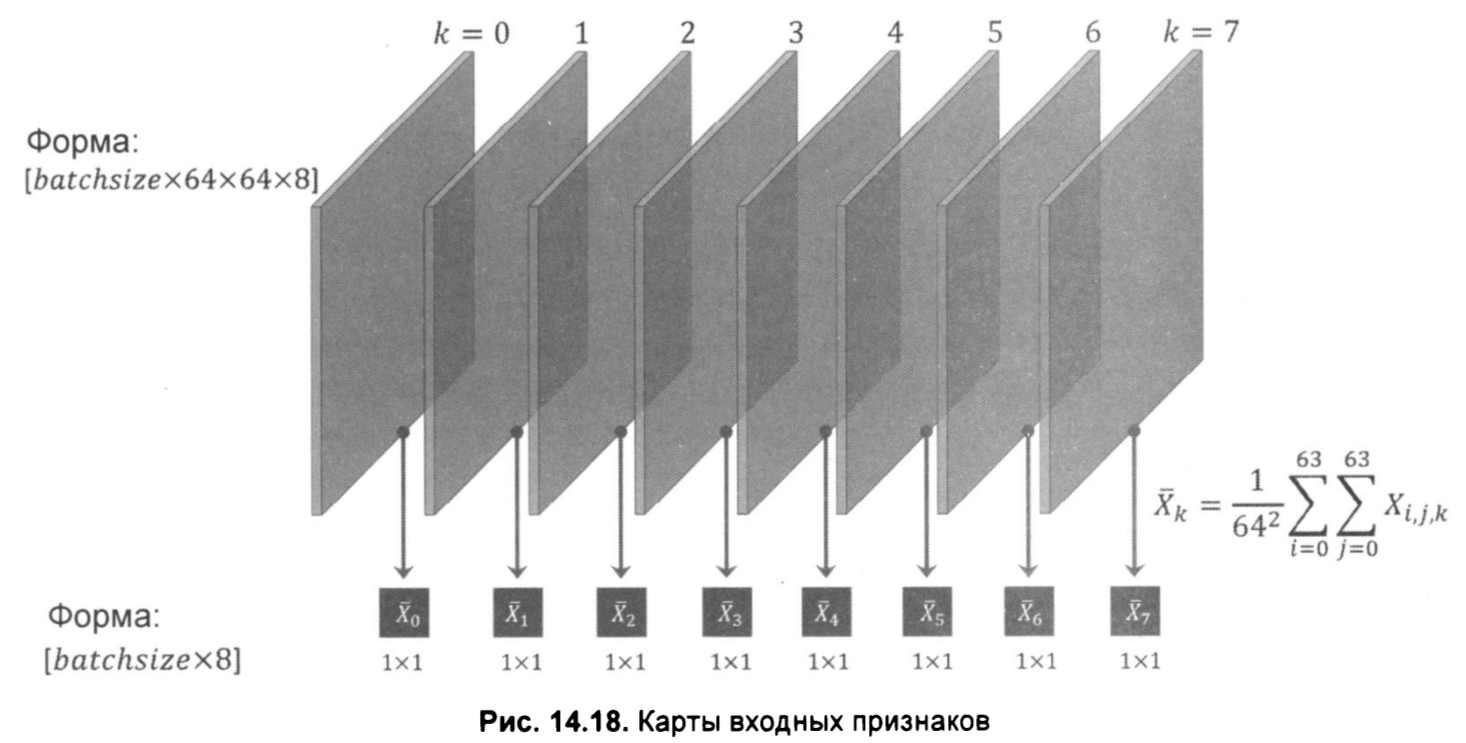

In [15]:
Image(filename='figures/14.18.png', width=700)

Таким образом, учитывая, что в нашем случае форма карт признаков до этого слоя равна [размер пакета х 256 х 8 х 8], мы ожидаем получить на выходе 256 узлов, т. е. форма на выходе будет [размер пакета х 256]. Давайте добавим этот слой и заново вычислим форму выхода, чтобы убедиться, что это так: 

In [16]:
# Добавляет слой среднего пулинга (Average Pooling) с окном 8×8.
# В отличие от MaxPool2d, который берёт максимальное значение в окне, AvgPool2d вычисляет среднее арифметическое всех значений в окне 8×8.
# Зачем: Усредняет пространственные признаки, агрегируя информацию по всей карте признаков. Это часто используется перед полносвязным слоем,
# чтобы уменьшить размерность и сделать модель более устойчивой к сдвигам.
# Что произойдёт с размером:
# На вход в этот слой поступает тензор размером [batch, 256, 8, 8] (после conv4 и relu4).
# При kernel_size=8 окно покрывает всю карту 8×8, поэтому после применения пулинга размерность по высоте и ширине становится 1×1.
# Выход: [batch, 256, 1, 1].
model.add_module('pool4', nn.AvgPool2d(kernel_size=8)) 
model.add_module('flatten', nn.Flatten()) 

x = torch.ones((4, 3, 64, 64))
model(x).shape

torch.Size([4, 256])

Наконец, можно добавить полносвязный слой, чтобы получить единственный выходной узел. В этом случае мы можем выбрать функцию активации sigmoid:

In [17]:
# Добавляет полносвязный (линейный) слой с именем 'fc' (от англ. fully connected).
# in_features=256 — на вход подаётся вектор из 256 признаков (как мы получили после Flatten()).
# out_features=1 — на выходе один нейрон.
# Зачем: Это слой классификации. Он преобразует вектор признаков размерности 256 в одно число (скаляр), которое будет интерпретироваться 
# как "уверенность" модели в том, что на изображении есть улыбка.
model.add_module('fc', nn.Linear(256, 1)) 
# Добавляет функцию активации Sigmoid.
# Формула: σ(x) = 1 / (1 + e^(-x)).
# Преобразует любое действительное число (от -∞ до +∞) в диапазон от 0 до 1.
# Зачем: Полученное значение можно интерпретировать как вероятность принадлежности к классу "улыбка". Например, 0.85 означает, что модель на 85% уверена, что на изображении улыбка, 0.12 — что улыбки нет.
model.add_module('sigmoid', nn.Sigmoid()) 

x = torch.ones((4, 3, 64, 64))
model(x).shape

torch.Size([4, 1])

In [18]:
model

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.5, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool4): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [19]:
device = torch.device("cuda:0")
# device = torch.device("cpu")
model = model.to(device) 

На следующем шаге мы создадим функции потерь и оптимизатора ( снова оптимизатор Adam). Для бинарной классификации с одним вероятностным выводом мы используем BCELoss для функции потерь: 

In [20]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device) 
            y_batch = y_batch.to(device) 
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch.float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()*y_batch.size(0)
            is_correct = ((pred>=0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)
        
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device) 
                y_batch = y_batch.to(device) 
                pred = model(x_batch)[:, 0]
                loss = loss_fn(pred, y_batch.float())
                loss_hist_valid[epoch] += loss.item()*y_batch.size(0) 
                is_correct = ((pred>=0.5).float() == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)
        
        print(f'Epoch {epoch+1} accuracy: {accuracy_hist_train[epoch]:.4f} val_accuracy: {accuracy_hist_valid[epoch]:.4f}')
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

torch.manual_seed(1)
num_epochs = 30
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.5099 val_accuracy: 0.5140
Epoch 2 accuracy: 0.5187 val_accuracy: 0.5140
Epoch 3 accuracy: 0.5257 val_accuracy: 0.5640
Epoch 4 accuracy: 0.5674 val_accuracy: 0.5930
Epoch 5 accuracy: 0.5982 val_accuracy: 0.6140
Epoch 6 accuracy: 0.6224 val_accuracy: 0.6560
Epoch 7 accuracy: 0.6623 val_accuracy: 0.6760
Epoch 8 accuracy: 0.6792 val_accuracy: 0.7020
Epoch 9 accuracy: 0.6929 val_accuracy: 0.7080
Epoch 10 accuracy: 0.7067 val_accuracy: 0.7560
Epoch 11 accuracy: 0.7330 val_accuracy: 0.7680
Epoch 12 accuracy: 0.7528 val_accuracy: 0.7760
Epoch 13 accuracy: 0.7604 val_accuracy: 0.7640
Epoch 14 accuracy: 0.7746 val_accuracy: 0.8000
Epoch 15 accuracy: 0.7879 val_accuracy: 0.8170
Epoch 16 accuracy: 0.7981 val_accuracy: 0.8160
Epoch 17 accuracy: 0.8090 val_accuracy: 0.8230
Epoch 18 accuracy: 0.8170 val_accuracy: 0.8310
Epoch 19 accuracy: 0.8271 val_accuracy: 0.8500
Epoch 20 accuracy: 0.8344 val_accuracy: 0.8580
Epoch 21 accuracy: 0.8360 val_accuracy: 0.8540
Epoch 22 accuracy: 0.8

Теперь построим кривую обучения и сравним потери и точность при обучении и валидации после каждой эпохи (рис. 14.19): 

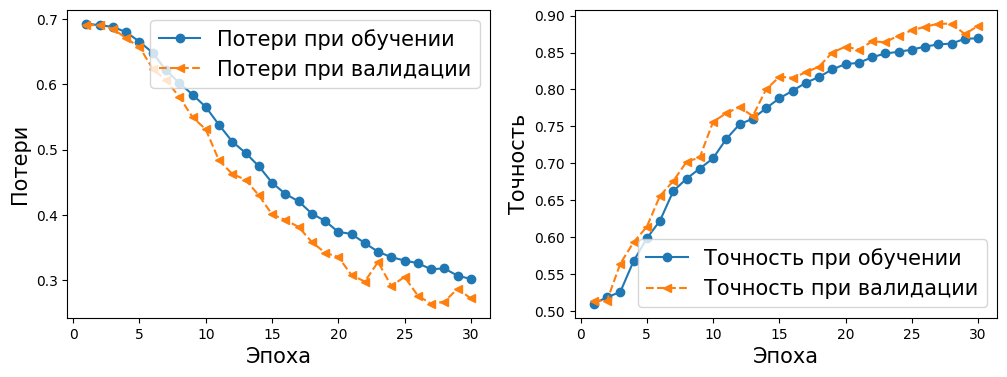

In [21]:
x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Потери при обучении')
ax.plot(x_arr, hist[1], '--<', label='Потери при валидации')
ax.legend(fontsize=15)
ax.set_xlabel('Эпоха', size=15)
ax.set_ylabel('Потери', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Точность при обучении')
ax.plot(x_arr, hist[3], '--<', label='Точность при валидации')
ax.legend(fontsize=15)
ax.set_xlabel('Эпоха', size=15)
ax.set_ylabel('Точность', size=15)

#plt.savefig('figures/14_17.png', dpi=300)
plt.show()

Если, судя по кривым, достигнут достаточный уровень обучения и точности, можно
перейти к оценке модели на наборе тестовых данных: 

In [22]:
accuracy_test = 0
# Переводишь модель в режим оценки:
# Dropout — отключается.
# BatchNorm — использует накопленную статистику, а не статистику батча.
# Это гарантирует, что модель работает так же, как при валидации/тестировании.
model.eval()
# Отключаешь вычисление градиентов.
# Зачем: Тестирование не требует обратного распространения. Это экономит память и ускоряет вычисления.
with torch.no_grad():
    for x_batch, y_batch in test_dl:
        x_batch = x_batch.to(device) 
        y_batch = y_batch.to(device) 
        pred = model(x_batch)[:, 0]
        is_correct = ((pred>=0.5).float() == y_batch).float()
        accuracy_test += is_correct.sum().cpu()
 
accuracy_test /= len(test_dl.dataset)
        
print(f'Test accuracy: {accuracy_test:.4f}') 

Test accuracy: 0.8916


Наконец, вы уже знаете, как получить результаты прогнозирования для нескольких тестовых примеров. В следующем коде мы возьмем небольшое подмножество в 10 примеров из последнего пакета нашего предварительно обработанного набора тестовых данных (test_dl). Затем вычислим вероятности того, что каждый пример относится к классу 1 (что соответствует наличию улыбки на основе меток, предоставленных в CelebA), и отобразим примеры вместе с их метками истинности (Ground Truth labels, GT) и предсказанными вероятностями (Probabilities, Pr): 

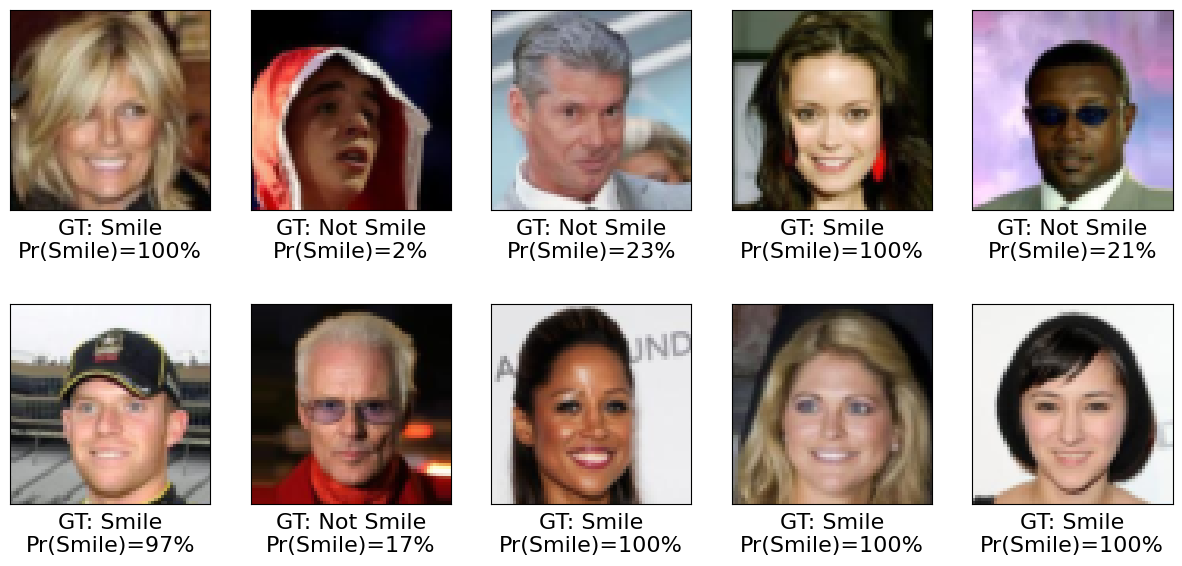

In [23]:
pred = model(x_batch)[:, 0] * 100

fig = plt.figure(figsize=(15, 7))
for j in range(10, 20):
    ax = fig.add_subplot(2, 5, j-10+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(x_batch[j].cpu().permute(1, 2, 0))
    if y_batch[j] == 1:
        label = 'Smile'
    else:
        label = 'Not Smile'
    ax.text(
        0.5, -0.15, 
        f'GT: {label:s}\nPr(Smile)={pred[j]:.0f}%', 
        size=16, 
        horizontalalignment='center',
        verticalalignment='center', 
        transform=ax.transAxes)
    
plt.show()

На рис. 14.20 показаны 10 примеров изображений вместе с их метками истинности и вероятностью того, что они принадлежат к классу 1 (улыбка).
Вероятности принадлежности к классу 1 (т. е. наличие улыбки по CelebA) приведены под каждым изображением. Как видите, наша обученная модель полностью точна на этом наборе из 10 тестовых примеров. В качестве дополнительного упражнения предлагаем читателям попробовать задействовать весь набор обучающих данных вместо созданного нами небольшого подмножества. Кроме того, вы можете модифицировать архитектуру CNN. Например, изменить
вероятность прореживания и количество фильтров в разных сверточных слоях. Кроме того, можно заменить глобальное объединение по среднему полностью подключенным слоем. Если вы используете весь обучающий набор данных с архитектурой CNN, которую мы обучали в этой главе, то сможете достичь точности выше 90%. 

In [24]:
import os
if not os.path.exists('models'):
    os.mkdir('models')

path = 'models/celeba-cnn.ph'
torch.save(model, path)

## Summary

В этой главе вы узнали о CNN и их основных компонентах. Мы начали с операции свертки и рассмотрели одномерные и двумерные реализации. Затем мы познакомились с другой разновидностью слоя, которая встречается в нескольких распространенных архитектурах CNN: подвыборкой, или объединением. В первую очередь мы сосредоточились на двух наиболее распространенных формах объединения: по максимальному и по среднему значению.
Затем, объединив все эти компоненты, мы создали глубокие CNN с помощью модуля torch.nn. Первую из созданных сетей мы применили к уже знакомой задаче распознавания рукописных цифр из набора MNIST, а вторую - к более сложному набору данных, состоящему из изображений лиц, и обучили CNN определять наличие улыбки . Попутно вы также узнали о дополнении данных и различных преобразованиях, которые мы можем применять к изображениям лиц с помощью модуля torchvision.transforms.

В следующей главе мы перейдем к рекуррентным нейронным сетям (Recurrent Neura\Network, RNN). Они предназначены для изучения структуры последовательных данных, и у них есть несколько интересных применений, включая языковой перевод и генерацию подписей к изображениям. 